In [1]:
import pandas as pd
import numpy as np

from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (77299, 11)
Test Shape: (41778, 10)


In [3]:
train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


In [5]:
train.isnull().sum()

Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

In [6]:
train["timestamp"].head(20)

0     0:0
1     0:0
2     0:0
3     0:0
4     0:0
5     0:0
6     0:0
7     0:0
8     0:0
9     0:0
10    0:0
11    0:0
12    0:0
13    0:0
14    0:0
15    0:0
16    0:0
17    0:0
18    0:0
19    0:0
Name: timestamp, dtype: object

In [7]:
print(train["timestamp"].nunique())

96


In [8]:
train["timestamp"].unique()[:20]

array(['0:0', '0:15', '0:30', '0:45', '1:0', '1:15', '1:30', '1:45',
       '2:0', '2:15', '2:30', '2:45', '3:0', '3:15', '3:30', '3:45',
       '4:0', '4:15', '4:30', '4:45'], dtype=object)

In [9]:
train["demand"].describe()

count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64

<Axes: >

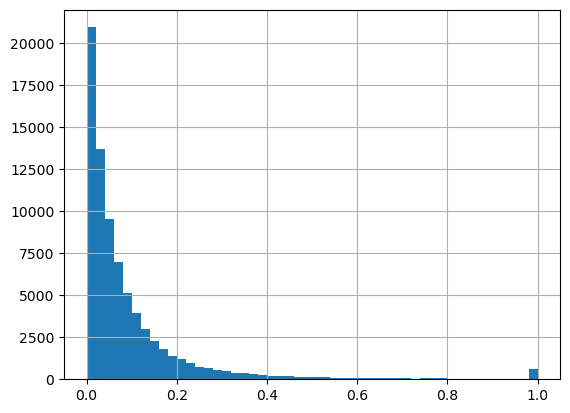

In [10]:
train["demand"].hist(bins=50)
#mean > median , so right skewed graph

In [11]:
train["demand"].min(), train["demand"].max()

(6.245650130093708e-07, 1.0)

In [12]:
#checking day attribute
train["day"].describe()

count    77299.000000
mean        48.101838
std          0.302438
min         48.000000
25%         48.000000
50%         48.000000
75%         48.000000
max         49.000000
Name: day, dtype: float64

In [13]:
print(train["day"].nunique())

2


In [14]:
sorted(train["day"].unique())[:20]

[np.int64(48), np.int64(49)]

In [15]:
sorted(train["day"].unique())[-20:]

[np.int64(48), np.int64(49)]

In [16]:
#how many unique locations exist
print(train["geohash"].nunique())

1249


In [17]:
train["geohash"].value_counts().head(10)

geohash
qp03xk    105
qp092r    105
qp03wz    105
qp03xp    105
qp097y    105
qp03r0    105
qp03r2    105
qp03xx    105
qp096y    105
qp096w    105
Name: count, dtype: int64

In [18]:
train["RoadType"].value_counts(dropna=False)

RoadType
Residential    69230
Street          3909
Highway         3560
NaN              600
Name: count, dtype: int64

In [19]:
train["Weather"].value_counts(dropna=False)

Weather
Sunny    27717
Rainy    20824
Foggy    20243
Snowy     7718
NaN        797
Name: count, dtype: int64

In [20]:
X = train.drop("demand", axis=1)
y = train["demand"]

In [21]:
X["timestamp"] = pd.to_datetime(X["timestamp"], format="%H:%M")
test["timestamp"] = pd.to_datetime(test["timestamp"], format="%H:%M")

In [22]:
X["hour"] = X["timestamp"].dt.hour
X["minute"] = X["timestamp"].dt.minute

test["hour"] = test["timestamp"].dt.hour
test["minute"] = test["timestamp"].dt.minute
#converting timestamp to hour and minute 

In [23]:
X = X.drop("timestamp", axis=1)
test = test.drop("timestamp", axis=1)
#removing old timestamp column

In [24]:
X.head()
#updated timestamp to hour and minute

,Index,geohash,day,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute
0,0,qp02z1,48,NaN,1,Not Allowed,No,NaN,NaN,0,0
1,1,qp02zt,48,Residential,3,Allowed,Yes,31.104565,Sunny,0,0
2,2,qp08bj,48,Residential,1,Not Allowed,No,25.919267,Sunny,0,0
3,3,qp08gt,48,Residential,1,Not Allowed,No,NaN,Rainy,0,0
4,4,qp02zq,48,Residential,1,Not Allowed,No,10.803667,Rainy,0,0


In [25]:
# Fill missing temperature values with median

temp_median = X["Temperature"].median()

X["Temperature"] = X["Temperature"].fillna(temp_median)
test["Temperature"] = test["Temperature"].fillna(temp_median)

In [26]:
X["RoadType"] = X["RoadType"].fillna("Missing")
test["RoadType"] = test["RoadType"].fillna("Missing")

X["Weather"] = X["Weather"].fillna("Missing")
test["Weather"] = test["Weather"].fillna("Missing")

In [27]:
X.isnull().sum()

Index            0
geohash          0
day              0
RoadType         0
NumberofLanes    0
LargeVehicles    0
Landmarks        0
Temperature      0
Weather          0
hour             0
minute           0
dtype: int64

In [28]:
categorical_cols = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather"
]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
print(X_train.shape)
print(X_valid.shape)

(61839, 11)
(15460, 11)


In [31]:
print(X_train.shape)
print(X_valid.shape)

print(y_train.shape)
print(y_valid.shape)

(61839, 11)
(15460, 11)
(61839,)
(15460,)


In [32]:
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_cols
)

0:	learn: 0.1369226	total: 483ms	remaining: 4m
100:	learn: 0.0445970	total: 33.8s	remaining: 2m 13s
200:	learn: 0.0400608	total: 1m 12s	remaining: 1m 48s
300:	learn: 0.0379243	total: 1m 54s	remaining: 1m 15s
400:	learn: 0.0360919	total: 2m 31s	remaining: 37.4s
499:	learn: 0.0349056	total: 3m 10s	remaining: 0us


CatBoostRegressor(depth=8, iterations=500, learning_rate=0.05, loss_function='RMSE', verbose=100)

In [33]:
preds = model.predict(X_valid)

score = r2_score(y_valid, preds)

print("Validation R2:", score)

Validation R2: 0.9346290367049852


In [34]:
test_preds = model.predict(test)
#predicting demand for actual test dataset

In [35]:
submission = pd.DataFrame({
    "Index": test["Index"],
    "demand": test_preds
})

submission.head()

,Index,demand
0,0,0.018434
1,1,0.015480
2,2,0.002381
3,3,0.022423
4,4,0.036152


In [36]:
submission.to_csv("submission_v1.csv", index=False)

print("Submission file created!")

Submission file created!


In [37]:
print(submission.shape)

(41778, 2)


In [39]:
print("hello world")

hello world


In [40]:
importance = model.get_feature_importance()

for feature, score in zip(X.columns, importance):
    print(feature, score)

Index 7.6166893899369414
geohash 20.481317133153965
day 0.0
RoadType 43.301046828220535
NumberofLanes 9.856340194451345
LargeVehicles 10.764924026677566
Landmarks 0.23551080757780785
Temperature 0.34923285858513925
Weather 0.5294743233298129
hour 6.775144948370601
minute 0.09031948969623911


In [41]:
importance = model.get_feature_importance()

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values("Importance", ascending=False)

print(feature_importance)

          Feature  Importance
3        RoadType   43.301047
1         geohash   20.481317
5   LargeVehicles   10.764924
4   NumberofLanes    9.856340
0           Index    7.616689
9            hour    6.775145
8         Weather    0.529474
7     Temperature    0.349233
6       Landmarks    0.235511
10         minute    0.090319
2             day    0.000000
